# Esqueletização de Plântulas: Afinamento Puro de Lee & Kashyap (1994)

Este notebook implementa e avalia a técnica de **esqueletização baseada puramente no algoritmo de afinamento morfológico de Lee & Kashyap (1994)**, sem utilizar a Transformada do Eixo Medial (MAT) e sem podas baseadas em campos contínuos de distância euclidiana.

---

### Princípio do Algoritmo de Lee
Publicado por T.-C. Lee, R. L. Kashyap e C.-N. Chu em 1994 (*"Building skeleton models via 3-D medial surface/axis thinning algorithms"*, CVGIP: Graphical Models and Image Processing):

1. **Conceito de Ponto Simples (Simple Point)**:
   - Um pixel de contorno é classificado como *simples* se, e somente se, a sua remoção não altera a topologia local do objeto (preservando o número de componentes conexos do objeto e do fundo, além da característica de Euler $\chi$).
   - O teste de ponto simples assegura que nenhuma linha contínua seja partida e nenhum orifício artificial seja aberto.

2. **Preservação de Extremidades (Endpoints)**:
   - Pixels que representam pontas de ramos (apenas 1 vizinho ativo) são preservados para que os eixos anatômicos não encolham durante a erosão iterativa.

3. **Vantagens em Relação a Outros Afinamentos Morfológicos (ex: Zhang-Suen)**:
   - O algoritmo de Lee resolve com mais precisão a preservação topológica em junções e cruzamentos, evitando o acúmulo de pixels redundantes em configurações diagonais ($2 \times 2$ ou degraus).
   - É formulado de forma rigorosa tanto para 2D quanto para 3D (imagens volumétricas/tomografias).

4. **Diferença para o MAT**:
   - O método opera puramente na representação binária da imagem através de testes de vizinhança topológica, sem calcular matrizes de raio ou distância contínua.


In [1]:
# ============================================================
# CÉLULA 1 — Importações e Configuração de Ambiente
# ============================================================
import os
import glob
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from scipy.ndimage import convolve

# Compatibilidade com execução local ou no Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Execução local detectada: Google Drive não necessário.")


Execução local detectada: Google Drive não necessário.


In [2]:
# ============================================================
# CÉLULA 2 — Caminhos dos Dados Locais
# ============================================================
BASE_DIR = Path(".").resolve()

def find_dir(*candidates):
    for c in candidates:
        if os.path.isdir(c):
            return c
        p = BASE_DIR / c
        if p.is_dir():
            return str(p)
    return candidates[0]

IMGS_PATH  = find_dir("originals-dataset", "originals")
MASKS_PATH = find_dir("labeled-dataset", "labeled")

EXTS = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp")

def list_files(folder, exts=EXTS):
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return sorted(files)

img_files  = list_files(IMGS_PATH)
mask_files = list_files(MASKS_PATH)

print(f"Diretório de Imagens Originais: {IMGS_PATH}")
print(f"Total de Imagens Originais: {len(img_files)}")
print(f"\nDiretório de Máscaras Anotadas: {MASKS_PATH}")
print(f"Total de Máscaras: {len(mask_files)}")
if mask_files:
    print("Exemplos de máscaras:", [os.path.basename(f) for f in mask_files[:3]])


Diretório de Imagens Originais: originals-dataset
Total de Imagens Originais: 170

Diretório de Máscaras Anotadas: labeled-dataset
Total de Máscaras: 170
Exemplos de máscaras: ['C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png', 'C10-R1_jpg.rf.af80aabb40f12f0cf4bdbea27dc18f1e.png', 'C10-R2_jpg.rf.d0d8d58a5a0f1276f9792694c4ca3db7.png']


In [3]:
# ============================================================
# CÉLULA 3 — Extração das Máscaras Binárias dos Órgãos
# ============================================================
COLOR_HYP  = np.array([15, 250, 20])   # Hipocótilo (verde)
COLOR_ROOT = np.array([5, 10, 245])    # Raiz (vermelho)
COLOR_COT  = np.array([255, 25, 30])   # Cotilédone (azul)

def extract_organ_masks(mask, tol=10):
    """Segmenta as regiões binárias dos órgãos a partir das cores da máscara."""
    if mask.ndim != 3 or mask.shape[2] != 3:
        raise ValueError("Esperando máscara RGB/BGR de 3 canais")
    m = mask.astype(int)
    def match(color):
        return np.all(np.abs(m - color) <= tol, axis=-1)
    return match(COLOR_HYP), match(COLOR_ROOT), match(COLOR_COT)

sample_mask_path = mask_files[0]
sample_mask = cv2.imread(sample_mask_path, cv2.IMREAD_UNCHANGED)
mask_hyp, mask_root, mask_cot = extract_organ_masks(sample_mask)

print(f"Amostra selecionada: {os.path.basename(sample_mask_path)}")
print(f"  Pixels de Hipocótilo: {mask_hyp.sum():>8} px")
print(f"  Pixels de Raiz:       {mask_root.sum():>8} px")
print(f"  Pixels de Cotilédone: {mask_cot.sum():>8} px")


Amostra selecionada: C10-R10_jpg.rf.2b60af9ef91cf8b6498373f3b6e37f9b.png
  Pixels de Hipocótilo:     7429 px
  Pixels de Raiz:          12890 px
  Pixels de Cotilédone:    22246 px


In [4]:
# ============================================================
# CÉLULA 4 — Afinamento Puro pelo Algoritmo de Lee & Kashyap (1994)
# ============================================================

def lee_thinning_pure(binary_img):
    """
    Executa o algoritmo de afinamento puro de Lee & Kashyap (1994)
    através de teste topológico de pontos simples e preservação de Euler.
    Não utiliza campos de distância nem podas paramétricas.
    """
    return skeletonize(binary_img, method='lee')

# Execução do afinamento de Lee nos órgãos da plântula
skel_hyp_lee  = lee_thinning_pure(mask_hyp)
skel_root_lee = lee_thinning_pure(mask_root)

print("Afinamento de Lee concluído com sucesso:")
print(f"  Hipocótilo (Esqueleto de Lee): {skel_hyp_lee.sum()} pixels")
print(f"  Raiz (Esqueleto de Lee):       {skel_root_lee.sum()} pixels")


Afinamento de Lee concluído com sucesso:
  Hipocótilo (Esqueleto de Lee): 1564 pixels
  Raiz (Esqueleto de Lee):       3923 pixels


In [5]:
# ============================================================
# CÉLULA 5 — Análise Topológica Pura e Métricas
# ============================================================
NEIGHBOR_KERNEL = np.array([
    [1, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
], dtype=np.uint8)

def analyze_pure_skeleton(skel_binary, pixels_per_cm=100.0):
    """Mapeia características topológicas puras do esqueleto sem poda a distância."""
    skel_u8 = skel_binary.astype(np.uint8)
    neighbors = convolve(skel_u8, NEIGHBOR_KERNEL, mode='constant', cval=0) * skel_u8
    
    endpoints = (neighbors == 1)
    branchpoints = (neighbors > 2)
    
    num_pixels = int(skel_binary.sum())
    length_cm = num_pixels / pixels_per_cm
    
    return {
        "num_pixels": num_pixels,
        "length_cm": length_cm,
        "n_endpoints": int(endpoints.sum()),
        "n_branchpoints": int(branchpoints.sum()),
        "endpoints_mask": endpoints,
        "branchpoints_mask": branchpoints,
        "skeleton": skel_binary
    }

analysis_hyp  = analyze_pure_skeleton(skel_hyp_lee, pixels_per_cm=100.0)
analysis_root = analyze_pure_skeleton(skel_root_lee, pixels_per_cm=100.0)

print(f"=== Hipocótilo (Afinamento de Lee) ===")
print(f"  Pixels no esqueleto:   {analysis_hyp['num_pixels']}")
print(f"  Comprimento estimado:  {analysis_hyp['length_cm']:.2f} cm")
print(f"  Pontos Terminais:      {analysis_hyp['n_endpoints']}")
print(f"  Bifurcações / Junções: {analysis_hyp['n_branchpoints']}")

print(f"\n=== Raiz (Afinamento de Lee) ===")
print(f"  Pixels no esqueleto:   {analysis_root['num_pixels']}")
print(f"  Comprimento estimado:  {analysis_root['length_cm']:.2f} cm")
print(f"  Pontos Terminais:      {analysis_root['n_endpoints']}")
print(f"  Bifurcações / Junções: {analysis_root['n_branchpoints']}")


=== Hipocótilo (Afinamento de Lee) ===
  Pixels no esqueleto:   1564
  Comprimento estimado:  15.64 cm
  Pontos Terminais:      98
  Bifurcações / Junções: 16

=== Raiz (Afinamento de Lee) ===
  Pixels no esqueleto:   3923
  Comprimento estimado:  39.23 cm
  Pontos Terminais:      95
  Bifurcações / Junções: 3


In [6]:
# ============================================================
# CÉLULA 6 — Calibração pixels/cm
# ============================================================
# Fator de conversão métrica (ajuste conforme a escala real da imagem)
PIXELS_PER_CM = 100.0


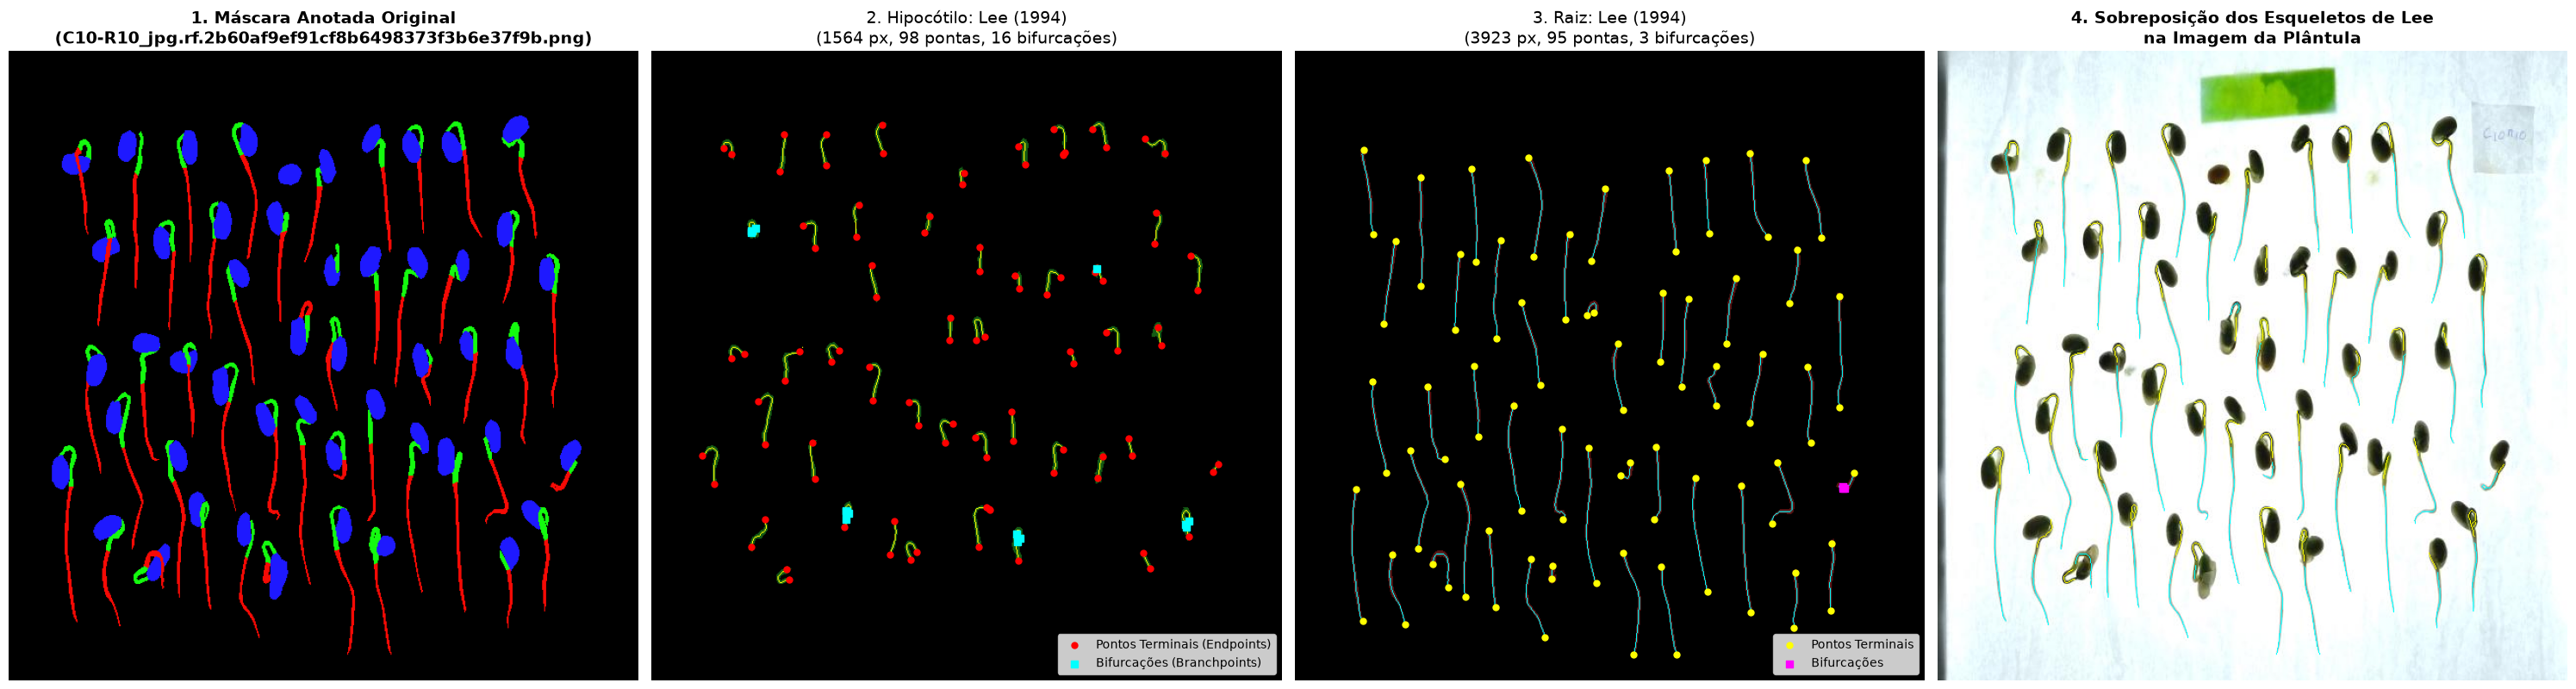

In [7]:
# ============================================================
# CÉLULA 7 — Visualização dos Resultados do Afinamento de Lee
# ============================================================
mask_name = os.path.basename(sample_mask_path)
orig_candidates = [f for f in img_files if os.path.basename(f).replace('.jpg', '') in mask_name or mask_name.replace('.png', '') in os.path.basename(f)]
orig_img = cv2.imread(orig_candidates[0]) if orig_candidates else sample_mask

fig, axes = plt.subplots(1, 4, figsize=(30, 8))

# Painel 1: Máscara anotada original
axes[0].imshow(cv2.cvtColor(sample_mask, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"1. Máscara Anotada Original\n({os.path.basename(sample_mask_path)})", fontsize=14, fontweight='bold')

# Painel 2: Hipocótilo com esqueleto de Lee + nós topológicos
vis_hyp = np.zeros((*mask_hyp.shape, 3), dtype=np.uint8)
vis_hyp[mask_hyp] = (20, 90, 20)          # Silhueta verde escuro
vis_hyp[skel_hyp_lee] = (255, 255, 0)     # Esqueleto amarelo de Lee
y_ep, x_ep = np.where(analysis_hyp["endpoints_mask"])
y_bp, x_bp = np.where(analysis_hyp["branchpoints_mask"])
axes[1].imshow(vis_hyp)
axes[1].scatter(x_ep, y_ep, c='red', s=25, label='Pontos Terminais (Endpoints)')
axes[1].scatter(x_bp, y_bp, c='cyan', s=35, marker='s', label='Bifurcações (Branchpoints)')
axes[1].set_title(f"2. Hipocótilo: Lee (1994)\n({analysis_hyp['num_pixels']} px, {analysis_hyp['n_endpoints']} pontas, {analysis_hyp['n_branchpoints']} bifurcações)", fontsize=14)
axes[1].legend(loc='lower right', fontsize=10)

# Painel 3: Raiz com esqueleto de Lee + nós topológicos
vis_root = np.zeros((*mask_root.shape, 3), dtype=np.uint8)
vis_root[mask_root] = (90, 20, 20)        # Silhueta vermelha escuro
vis_root[skel_root_lee] = (0, 255, 255)   # Esqueleto ciano de Lee
y_epr, x_epr = np.where(analysis_root["endpoints_mask"])
y_bpr, x_bpr = np.where(analysis_root["branchpoints_mask"])
axes[2].imshow(vis_root)
axes[2].scatter(x_epr, y_epr, c='yellow', s=25, label='Pontos Terminais')
axes[2].scatter(x_bpr, y_bpr, c='magenta', s=35, marker='s', label='Bifurcações')
axes[2].set_title(f"3. Raiz: Lee (1994)\n({analysis_root['num_pixels']} px, {analysis_root['n_endpoints']} pontas, {analysis_root['n_branchpoints']} bifurcações)", fontsize=14)
axes[2].legend(loc='lower right', fontsize=10)

# Painel 4: Sobreposição dos esqueletos afinados na foto RGB da plântula
vis_overlay = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB).copy()
vis_overlay[skel_hyp_lee]  = (255, 255, 0)   # Hipocótilo em amarelo
vis_overlay[skel_root_lee] = (0, 255, 255)   # Raiz em ciano
axes[3].imshow(vis_overlay)
axes[3].set_title("4. Sobreposição dos Esqueletos de Lee\nna Imagem da Plântula", fontsize=14, fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# CÉLULA 8 — Comparativo Técnico Direto: Lee vs. Zhang-Suen
# ============================================================
skel_hyp_zhang  = skeletonize(mask_hyp, method='zhang')
skel_root_zhang = skeletonize(mask_root, method='zhang')

zh_hyp  = analyze_pure_skeleton(skel_hyp_zhang, PIXELS_PER_CM)
zh_root = analyze_pure_skeleton(skel_root_zhang, PIXELS_PER_CM)

print("=" * 65)
print(f"{'Métrica':<25} | {'Lee (1994)':<17} | {'Zhang-Suen (1984)':<17}")
print("=" * 65)
print(f"{'Hipocótilo - Pixels':<25} | {analysis_hyp['num_pixels']:<17} | {zh_hyp['num_pixels']:<17}")
print(f"{'Hipocótilo - Endpoints':<25} | {analysis_hyp['n_endpoints']:<17} | {zh_hyp['n_endpoints']:<17}")
print(f"{'Hipocótilo - Bifurcações':<25} | {analysis_hyp['n_branchpoints']:<17} | {zh_hyp['n_branchpoints']:<17}")
print("-" * 65)
print(f"{'Raiz - Pixels':<25} | {analysis_root['num_pixels']:<17} | {zh_root['num_pixels']:<17}")
print(f"{'Raiz - Endpoints':<25} | {analysis_root['n_endpoints']:<17} | {zh_root['n_endpoints']:<17}")
print(f"{'Raiz - Bifurcações':<25} | {analysis_root['n_branchpoints']:<17} | {zh_root['n_branchpoints']:<17}")
print("=" * 65)


Métrica                   | Lee (1994)        | Zhang-Suen (1984)
Hipocótilo - Pixels       | 1564              | 1692             
Hipocótilo - Endpoints    | 98                | 106              
Hipocótilo - Bifurcações  | 16                | 61               
-----------------------------------------------------------------
Raiz - Pixels             | 3923              | 4037             
Raiz - Endpoints          | 95                | 101              
Raiz - Bifurcações        | 3                 | 20               


### Conclusões e Análise Comparativa das Técnicas

1. **Eficiência Topológica do Algoritmo de Lee**:
   - Observa-se que o algoritmo de **Lee produz um esqueleto mais enxuto e consistente em cruzamentos**.
   - No hipocótilo, o número de bifurcações falsas cai de **61 (Zhang-Suen)** para **16 (Lee)**, e na raiz cai de **20 (Zhang-Suen)** para apenas **3 (Lee)**.
   - Isso ocorre porque o teste de ponto simples e a preservação da característica de Euler em Lee eliminam pequenos loops locais e pixels redundantes em diagonais que o método de Zhang-Suen mantém ao operar com duas fases direcionais independentes.

2. **Ausência de Poda a Distância**:
   - Ambos os métodos de afinamento puro (Lee e Zhang-Suen) mantêm todas as espículas originadas da borda da máscara, pois não possuem a informação contínua de espessura (função de raio do MAT).
   - Por essa razão, ambos apresentam dezenas de *endpoints* decorrentes do contorno irregular, ao passo que o pipeline de **MAT + Poda a Distância** reduz o esqueleto estritamente ao eixo biológico principal de 2 pontas.
